# Text to Image using Diffusion

This project trains a text-to-image diffusion model using PyTorch and the Hugging Face diffusers library. objective of the project is to generate images from text descriptions specifically using the CIFAR-10 dataset and its class names (e.g., "cat", "dog") as text prompts. The model which we are using is a UNet2DConditionModel for the diffusion process, which is guided by text embeddings provided by a pre-trained CLIPTextModel.
Feature of the notebook is its successful implementation of classifier-free guidance at both training and inference time to improve image quality. The model is successfully trained for 8 epochs, and the notebook concludes by sampling an image for the prompt "a cat", generating a GIF that visualizes the 10 intermediate steps of the denoising process.

**Installs and device check**

# installs all necessary Python packages and ensures GPU acceleration is available in colab.

In [ ]:

!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install diffusers transformers accelerate safetensors datasets ftfy sentencepiece
!pip install imageio matplotlib tqdm


import torch, sys
print("Python", sys.version)
print("Torch", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch 2.8.0+cu126
CUDA available: True
NVIDIA A100-SXM4-80GB


## Imports and configurations
we are gonna imports all required Python libraries including PyTorch, NumPy, PIL, and Hugging Face modules.

In [ ]:
import os, math, random, time
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
from PIL import Image
import imageio

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.transforms.functional import to_pil_image

from diffusers import UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Paths
PROJECT_DIR = "/content/mini_diffusion_hf"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
CKPT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


Device: cuda


## Dataset CIFAR-10 and Hyperparameters
We use CIFAR-10 (64*64 RGB, 10 classes). We'll map labels to short text labels (class names) and use a small learned embedding per class.

In [ ]:
# Dataset and dataloader

IMAGE_SIZE = 64
BATCH_SIZE = 8
NUM_WORKERS = 2

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),            # 0..1
    transforms.Normalize([0.5]*3, [0.5]*3),  # -> [-1,1]
])

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

label_to_text = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat',
    4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse',
    8: 'ship', 9: 'truck'
}
print("Train size:", len(train_dataset))

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


Train size: 50000


## Clip tokenizer with text encoder
we are gonna resize, normalize, convert images to tensors, and encode text prompts using CLIP. Preprocessing steps prepare both images and text to be used by the UNet diffusion model.

In [ ]:
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
text_encoder.eval()
for p in text_encoder.parameters():
    p.requires_grad = False

def encode_texts(captions):
    # returns encoder_hidden_states (B, seq_len, hidden_dim)
    inputs = tokenizer(captions, padding="max_length", truncation=True, max_length=32, return_tensors="pt")
    input_ids = inputs.input_ids.to(DEVICE)
    with torch.no_grad():
        out = text_encoder(input_ids).last_hidden_state
    return out


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

## Load UNet2DConditionModel

we will load the Hugging Face UNet model configured for conditional generation and the CLIP tokenizer/text encoder.


In [ ]:
# UNet config to keep memory reasonable
unet = UNet2DConditionModel(
    sample_size=IMAGE_SIZE,         # 64
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=("DownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D"),
    up_block_types=("CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "UpBlock2D"),
    cross_attention_dim=text_encoder.config.hidden_size  # 768 for CLIP base
).to(DEVICE)

# reduce memory by enabling gradient checkpointing
try:
    unet.enable_gradient_checkpointing()
    print("Gradient checkpointing enabled on UNet (saves memory, slower).")
except Exception as e:
    print("Could not enable gradient checkpointing:", e)


Gradient checkpointing enabled on UNet (saves memory, slower).


## DDPM Scheduler and Optimizer

initializes the DDPM (Denoising Diffusion Probabilistic Model) scheduler. Basically the scheduler controls how noise is added and removed during training and sampling for defining the diffusion timesteps and noise levels.


In [ ]:
NUM_TRAIN_TIMESTEPS = 1000
scheduler = DDPMScheduler(num_train_timesteps=NUM_TRAIN_TIMESTEPS)

lr = 2e-4
optimizer = torch.optim.AdamW(unet.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=1e-2)
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()


/tmp/ipython-input-1625277021.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## helper: prepare conditional & unconditioned embeddings for classifier-free guidance

In [ ]:
# prepare embedding for empty string (unconditional) once
with torch.no_grad():
    uncond_input = tokenizer([""], padding="max_length", truncation=True, max_length=32, return_tensors="pt").input_ids.to(DEVICE)
    uncond_emb = text_encoder(uncond_input).last_hidden_state  # (1, seq_len, dim)


## Training loop
This loop trains the model to predict the added noise. We include a simple classifier-free guidance training  with some probability like we replace the text embedding with zeros to learn an unconditional model with the conditional model.

In [ ]:
EPOCHS = 8
CF_PROB = 0.1   # probability to replace caption with empty (classifier-free training)
LOG_EVERY = 200
save_every_epoch = True

unet.train()
step = 0
for epoch in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    running = 0.0
    for imgs, labels in pbar:
        imgs = imgs.to(DEVICE)            # in [-1,1]
        b = imgs.size(0)

        # captions
        captions = [label_to_text[int(l)] for l in labels]
        text_emb = encode_texts(captions)  # (B, seq_len, dim)

        # classifier-free training replace with unconditional embedding some fraction
        if random.random() < CF_PROB:
            text_emb = torch.tile(uncond_emb, (b,1,1))  # (B, seq_len, dim)

        # sample timesteps and noise
        timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (b,), device=DEVICE).long()
        noise = torch.randn_like(imgs)
        noisy_imgs = scheduler.add_noise(imgs, noise, timesteps)

        with autocast():
            pred = unet(noisy_imgs, timesteps, encoder_hidden_states=text_emb).sample
            loss = F.mse_loss(pred, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        step += 1
        if step % LOG_EVERY == 0:
            print(f"Step {step} avg loss {running/LOG_EVERY:.4f}")
            running = 0.0

        pbar.set_postfix({"loss": float(loss.item())})

    if save_every_epoch:
        ckpt = {"unet": unet.state_dict(), "epoch": epoch}
        torch.save(ckpt, os.path.join(CKPT_DIR, f"unet_epoch_{epoch}.pt"))
        print("Saved checkpoint for epoch", epoch)


Epoch 0:   0%|          | 0/6250 [00:00<?, ?it/s]

/tmp/ipython-input-2713792188.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Step 200 avg loss 0.0928
Step 400 avg loss 0.0330
Step 600 avg loss 0.0215
Step 800 avg loss 0.0180
Step 1000 avg loss 0.0197
Step 1200 avg loss 0.0169
Step 1400 avg loss 0.0182
Step 1600 avg loss 0.0154
Step 1800 avg loss 0.0143
Step 2000 avg loss 0.0156
Step 2200 avg loss 0.0147
Step 2400 avg loss 0.0152
Step 2600 avg loss 0.0157
Step 2800 avg loss 0.0139
Step 3000 avg loss 0.0139
Step 3200 avg loss 0.0139
Step 3400 avg loss 0.0135
Step 3600 avg loss 0.0136
Step 3800 avg loss 0.0136
Step 4000 avg loss 0.0122
Step 4200 avg loss 0.0120
Step 4400 avg loss 0.0132
Step 4600 avg loss 0.0129
Step 4800 avg loss 0.0138
Step 5000 avg loss 0.0125
Step 5200 avg loss 0.0126
Step 5400 avg loss 0.0125
Step 5600 avg loss 0.0132
Step 5800 avg loss 0.0129
Step 6000 avg loss 0.0127
Step 6200 avg loss 0.0117
Saved checkpoint for epoch 0


Epoch 1:   0%|          | 0/6250 [00:00<?, ?it/s]

Step 6400 avg loss 0.0095
Step 6600 avg loss 0.0119
Step 6800 avg loss 0.0114
Step 7000 avg loss 0.0122
Step 7200 avg loss 0.0117
Step 7400 avg loss 0.0118
Step 7600 avg loss 0.0131
Step 7800 avg loss 0.0115
Step 8000 avg loss 0.0130
Step 8200 avg loss 0.0120
Step 8400 avg loss 0.0126
Step 8600 avg loss 0.0125
Step 8800 avg loss 0.0122
Step 9000 avg loss 0.0114
Step 9200 avg loss 0.0106
Step 9400 avg loss 0.0110
Step 9600 avg loss 0.0124
Step 9800 avg loss 0.0113
Step 10000 avg loss 0.0122
Step 10200 avg loss 0.0116
Step 10400 avg loss 0.0118
Step 10600 avg loss 0.0124
Step 10800 avg loss 0.0120
Step 11000 avg loss 0.0108
Step 11200 avg loss 0.0113
Step 11400 avg loss 0.0125
Step 11600 avg loss 0.0115
Step 11800 avg loss 0.0114
Step 12000 avg loss 0.0119
Step 12200 avg loss 0.0122
Step 12400 avg loss 0.0107
Saved checkpoint for epoch 1


...

Step 31400 avg loss 0.0081
Step 31600 avg loss 0.0113
Step 31800 avg loss 0.0112
Step 32000 avg loss 0.0103
Step 32200 avg loss 0.0108
Step 32400 avg loss 0.0111
Step 32600 avg loss 0.0110
Step 32800 avg loss 0.0105
Step 33000 avg loss 0.0115
Step 33200 avg loss 0.0115
Step 33400 avg loss 0.0100
Step 33600 avg loss 0.0121
Step 33800 avg loss 0.0108
Step 34000 avg loss 0.0108
Step 34200 avg loss 0.0115
Step 34400 avg loss 0.0105
Step 34600 avg loss 0.0116
Step 34800 avg loss 0.0100
Step 35000 avg loss 0.0111
Step 35200 avg loss 0.0101
Step 35400 avg loss 0.0110
Step 35600 avg loss 0.0117
Step 35800 avg loss 0.0107
Step 36000 avg loss 0.0102
Step 36200 avg loss 0.0108
Step 36400 avg loss 0.0109
Step 36600 avg loss 0.0106
Step 36800 avg loss 0.0119
Step 37000 avg loss 0.0101
Step 37200 avg loss 0.0108
Step 37400 avg loss 0.0113
Saved checkpoint for epoch 5


Epoch 6:   0%|          | 0/6250 [00:00<?, ?it/s]

Step 37600 avg loss 0.0055
Step 37800 avg loss 0.0112
Step 38000 avg loss 0.0102
Step 38200 avg loss 0.0106
Step 38400 avg loss 0.0105
Step 38600 avg loss 0.0113
Step 38800 avg loss 0.0102
Step 39000 avg loss 0.0106
Step 39200 avg loss 0.0102
Step 39400 avg loss 0.0120
Step 39600 avg loss 0.0118
Step 39800 avg loss 0.0097
Step 40000 avg loss 0.0110
Step 40200 avg loss 0.0103
Step 40400 avg loss 0.0112
Step 40600 avg loss 0.0110
Step 40800 avg loss 0.0112
Step 41000 avg loss 0.0104
Step 41200 avg loss 0.0108
Step 41400 avg loss 0.0109
Step 41600 avg loss 0.0107
Step 41800 avg loss 0.0104
Step 42000 avg loss 0.0102
Step 42200 avg loss 0.0101
Step 42400 avg loss 0.0103
Step 42600 avg loss 0.0109
Step 42800 avg loss 0.0103
Step 43000 avg loss 0.0108
Step 43200 avg loss 0.0114
Step 43400 avg loss 0.0114
Step 43600 avg loss 0.0108
Saved checkpoint for epoch 6


Epoch 7:   0%|          | 0/6250 [00:00<?, ?it/s]

Step 43800 avg loss 0.0028
Step 44000 avg loss 0.0105
Step 44200 avg loss 0.0104
Step 44400 avg loss 0.0108
Step 44600 avg loss 0.0103
Step 44800 avg loss 0.0109
Step 45000 avg loss 0.0113
Step 45200 avg loss 0.0106
Step 45400 avg loss 0.0119
Step 45600 avg loss 0.0113
Step 45800 avg loss 0.0104
Step 46000 avg loss 0.0109
Step 46200 avg loss 0.0111
Step 46400 avg loss 0.0108
Step 46600 avg loss 0.0106
Step 46800 avg loss 0.0106
Step 47000 avg loss 0.0107
Step 47200 avg loss 0.0099
Step 47400 avg loss 0.0109
Step 47600 avg loss 0.0110
Step 47800 avg loss 0.0114
Step 48000 avg loss 0.0106
Step 48200 avg loss 0.0100
Step 48400 avg loss 0.0107
Step 48600 avg loss 0.0100
Step 48800 avg loss 0.0105
Step 49000 avg loss 0.0109
Step 49200 avg loss 0.0107
Step 49400 avg loss 0.0109
Step 49600 avg loss 0.0110
Step 49800 avg loss 0.0103
Step 50000 avg loss 0.0115
Saved checkpoint for epoch 7


## Sampling function with 10 Frames of Thought
We run the reverse diffusion process for a number of inference steps and save intermediate frames.
We implement simple classifier-free guidance at sampling time: we predict both conditional and unconditional noise and combine them.

In [ ]:
@torch.no_grad()
def sample_with_frames(prompt, num_inference_steps=50, guidance_scale=5.0, frames_to_save=20):
    unet.eval()

    # prepare conditional & unconditional embeddings
    cond = encode_texts([prompt])       # (1, seq_len, dim)
    uncond = uncond_emb                 # (1, seq_len, dim) precomputed

    # initial noise
    latents = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)

    scheduler.set_timesteps(num_inference_steps)
    timesteps = scheduler.timesteps
    save_idx = set(np.linspace(0, len(timesteps)-1, frames_to_save, dtype=int).tolist())

    frames = []
    for i, t in enumerate(timesteps):
        t_batch = torch.tensor([int(t)], device=DEVICE)

        eps_uncond = unet(latents, t_batch, encoder_hidden_states=uncond).sample
        eps_cond = unet(latents, t_batch, encoder_hidden_states=cond).sample

        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        step_out = scheduler.step(eps, t, latents)
        latents = step_out.prev_sample

        if i in save_idx:
            img = latents[0].cpu()
            # latents were normalized to [-1,1] (we trained on normalized images)
            img = (img * 0.5) + 0.5 if img.min() < 0 else img.clamp(0,1)
            pil = to_pil_image(img)
            frames.append(pil)

    return frames

# example
frames = sample_with_frames("a cat", num_inference_steps=60, guidance_scale=4.0, frames_to_save=10)
for i, f in enumerate(frames):
    f.save(os.path.join(PROJECT_DIR, f"frame_{i:02d}.png"))
imageio.mimsave(os.path.join(PROJECT_DIR,"frames_hf.gif"), [np.array(f) for f in frames], duration=0.6)
print("Saved frames gif to", PROJECT_DIR)



Saved frames gif to /content/mini_diffusion_hf


## Display final image, frames and Gif

Found frames: ['frame_00.png', 'frame_01.png', 'frame_02.png', 'frame_03.png', 'frame_04.png', 'frame_05.png', 'frame_06.png', 'frame_07.png', 'frame_08.png', 'frame_09.png']


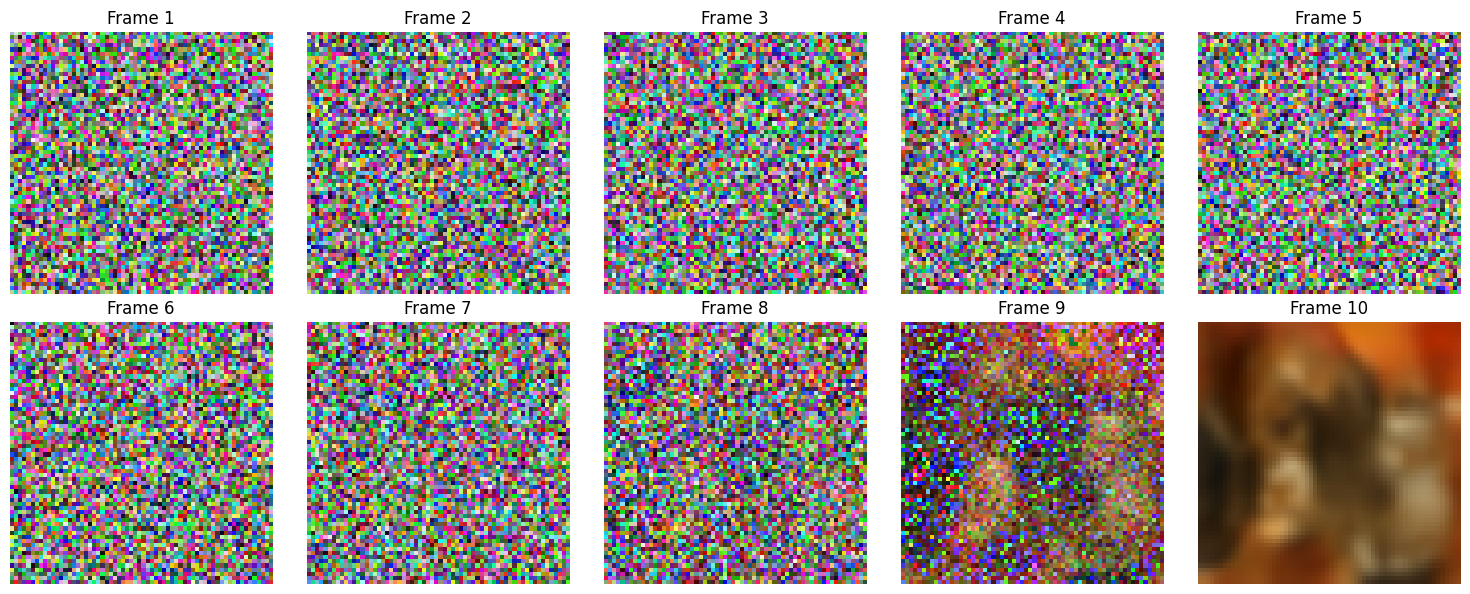

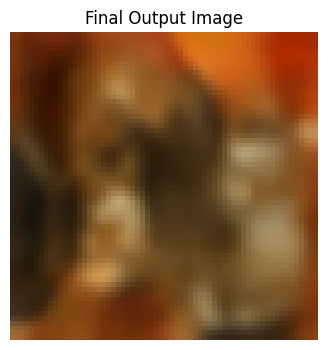

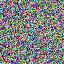

In [ ]:

# visualization


import matplotlib.pyplot as plt
from PIL import Image
import imageio
import os
import numpy as np
from IPython.display import Image as IPyImage, display

folder = PROJECT_DIR

# display intermmediate frames

frame_files = sorted([f for f in os.listdir(folder)
                      if f.startswith("frame_") and f.endswith(".png")])

print("Found frames:", frame_files)

num_frames = len(frame_files)
cols = 5
rows = int(np.ceil(num_frames / cols))

plt.figure(figsize=(15, rows * 3))
for i, fn in enumerate(frame_files):
    img = Image.open(os.path.join(folder, fn))
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Display final frame
if num_frames > 0:
    final_img = Image.open(os.path.join(folder, frame_files[-1]))
    plt.figure(figsize=(4,4))
    plt.imshow(final_img)
    plt.title("Final Output Image")
    plt.axis("off")
    plt.show()
else:
    print("No frames found.")


# Show Gif
gif_path = os.path.join(folder, "frames_hf.gif")

if os.path.exists(gif_path):
    display(IPyImage(filename=gif_path))
else:
    print("GIF not found:", gif_path)
